# Clustering Analysis - NYC Urban Demand Intelligence Platform

## Objective

The goal of this analysis is to identify distinct demand behavior patterns in NYC taxi activity using unsupervised learning.

By clustering zone-hour observations, we aim to uncover recurring demand regimes that can support:

- demand forecasting
- pricing strategy
- driver allocation
- operational planning

This analysis focuses on behavioral segmentation rather than geographic segmentation.

## Data Description

The dataset consists of NYC Yellow Taxi trips from January to March 2019.

Data is aggregated at the **zone × hour level**, where each observation represents taxi activity within a specific zone and hour.

### Key Features

- demand: number of completed rides (target variable)
- avg_fare: average fare per ride
- avg_distance: average trip distance
- hour: hour of the day
- day_of_week: day of the week
- is_weekend: weekend indicator
- zone_id: taxi zone identifier

This aggregation allows us to analyze temporal demand behavior across the city.

## Methodology

### Feature Preparation

Numerical features were standardized to ensure equal contribution to clustering.

### Clustering Algorithm

KMeans clustering was applied to identify patterns in demand behavior.

### Selection of Number of Clusters

The optimal number of clusters (K = 4) was selected using:

- elbow method
- silhouette score
- interpretability considerations

### Important Note

Clusters represent **demand behavior patterns**, not fixed geographic regions.

The same zone may belong to different clusters at different times.

## Cluster Overview

The clustering analysis identified four distinct demand regimes:

- Cluster 0: Low-demand off-peak activity
- Cluster 1: High-demand peak-hour activity
- Cluster 2: Medium-demand mixed activity
- Cluster 3: Lower-frequency high-value trips

These clusters capture differences in demand intensity, trip characteristics, and temporal behavior.

## Cluster Characteristics

The following visualizations compare key features across clusters, highlighting differences in demand levels, pricing, and trip distance.

In [1]:
import pandas as pd

DATA_PATH = "../../data/processed/zone_hour_clusters.parquet"

df = pd.read_parquet(DATA_PATH)
df.head()

,zone_id,pickup_hour_ts,demand,avg_fare,avg_distance,hour,day_of_week,is_weekend,day,month,cluster
0,1,2019-01-01 10:00:00,2,61.25,16.90,10,1,0,1,1,3
1,1,2019-01-01 12:00:00,1,135.00,19.30,12,1,0,1,1,3
2,1,2019-01-01 15:00:00,1,106.00,41.28,15,1,0,1,1,3
3,1,2019-01-02 02:00:00,1,30.00,1.27,2,2,0,2,1,1
4,1,2019-01-02 03:00:00,1,15.00,12.65,3,2,0,2,1,1


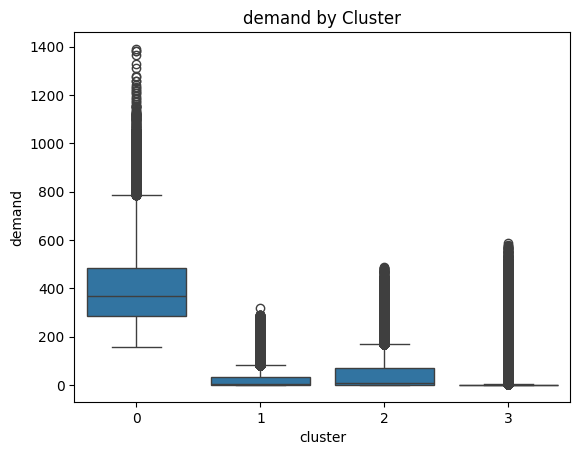

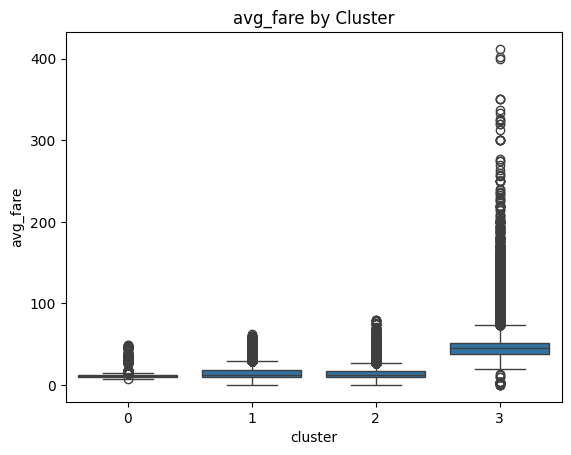

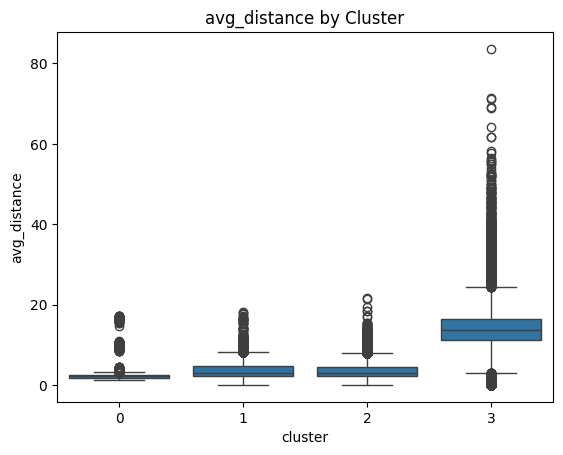

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ["demand", "avg_fare", "avg_distance"]

for feature in features:
    plt.figure()
    sns.boxplot(x="cluster", y=feature, data=df)
    plt.title(f"{feature} by Cluster")
    plt.show()

## Business Personas

To make clustering results actionable, each cluster is translated into a business persona.

- Off-peak low-demand periods represent background system usage
- Peak-hour demand captures the core operational load of the system
- Baseline activity reflects stable, city-wide demand patterns
- High-value trips represent economically significant but less frequent rides

## Key Insights

- Demand in NYC taxi data is highly segmented across time and behavior patterns
- Peak-hour demand represents the core operational load and requires careful capacity planning
- Off-peak demand is stable and predictable but contributes less to overall volume
- High-value trips, while less frequent, contribute disproportionately to revenue
- Mixed-demand periods provide a stable baseline of activity across the city


## Business Implications

The identified personas can be directly used to improve operational and strategic decisions:

### Driver Allocation
- Increase driver supply during peak-hour demand periods
- Reduce oversupply during off-peak hours

### Pricing Strategy
- Apply dynamic pricing in high-demand segments
- Optimize pricing for high-value long-distance trips

### Demand Forecasting
- Build separate models for different personas to improve accuracy

### Product Strategy
- Tailor services for different demand regimes (e.g., airport rides vs commuting)

## Limitations

- Clustering results depend on selected features and scaling
- Temporal dynamics beyond hourly aggregation are not captured
- External factors such as weather and events are not fully incorporated